In [17]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ==========================================
# 1. CONFIGURATION & LOADING
# ==========================================
DATA_DIR="/share/data1/mossf/data/brainlm"
OUTPUT_DIR=f"{DATA_DIR}/outputs/attention_matrices/"

# Find all attention matrix files
file_pattern = os.path.join(OUTPUT_DIR, "*_attention.npy")
file_paths = glob.glob(file_pattern)

if not file_paths:
    raise FileNotFoundError(f"No .npy files found in {OUTPUT_DIR}. Check your path!")

print(f"Found {len(file_paths)} subject matrices. Loading...")

# Load all matrices into a list
all_subject_matrices = []
full_matrix = []
for file_path in file_paths:
    # Load the float32 matrix
    mat = np.load(file_path)
    # Lets do batch 3 (in the middle of the signal) and reshape
    num_windows = 10
    num_regions = 424
    att = mat[3].reshape(num_windows, num_regions, num_windows, num_regions)
    avg_shifted_attention = np.stack([
        att[t, :, t+1, :]
        for t in range(num_windows - 1)
    ]).mean(axis=0)  # [num_regions, num_regions]

    all_subject_matrices.append(avg_shifted_attention)
    full_matrix.append(mat)

# Stack them into a single 3D numpy array: [num_subjects, 424, 424]
population_tensor = np.stack(all_subject_matrices, axis=0)
population_tensor_full = np.stack(full_matrix, axis=0)
print(f"Population Tensor Shape: {population_tensor.shape}")

# ==========================================
# 2. COMPUTE GRAND AVERAGE
# ==========================================
# Average across the subject dimension (axis 0)
grand_avg_matrix = np.mean(population_tensor, axis=0)
grand_avg_matrix_full = np.mean(population_tensor_full, axis=0)
print(f"Grand Average Matrix Shape: {grand_avg_matrix.shape}")
print(f"Grand Average FUll Matrix Shape: {grand_avg_matrix_full.shape}")


Found 100 subject matrices. Loading...
Population Tensor Shape: (100, 424, 424)
Grand Average Matrix Shape: (424, 424)
Grand Average FUll Matrix Shape: (5, 4240, 4240)


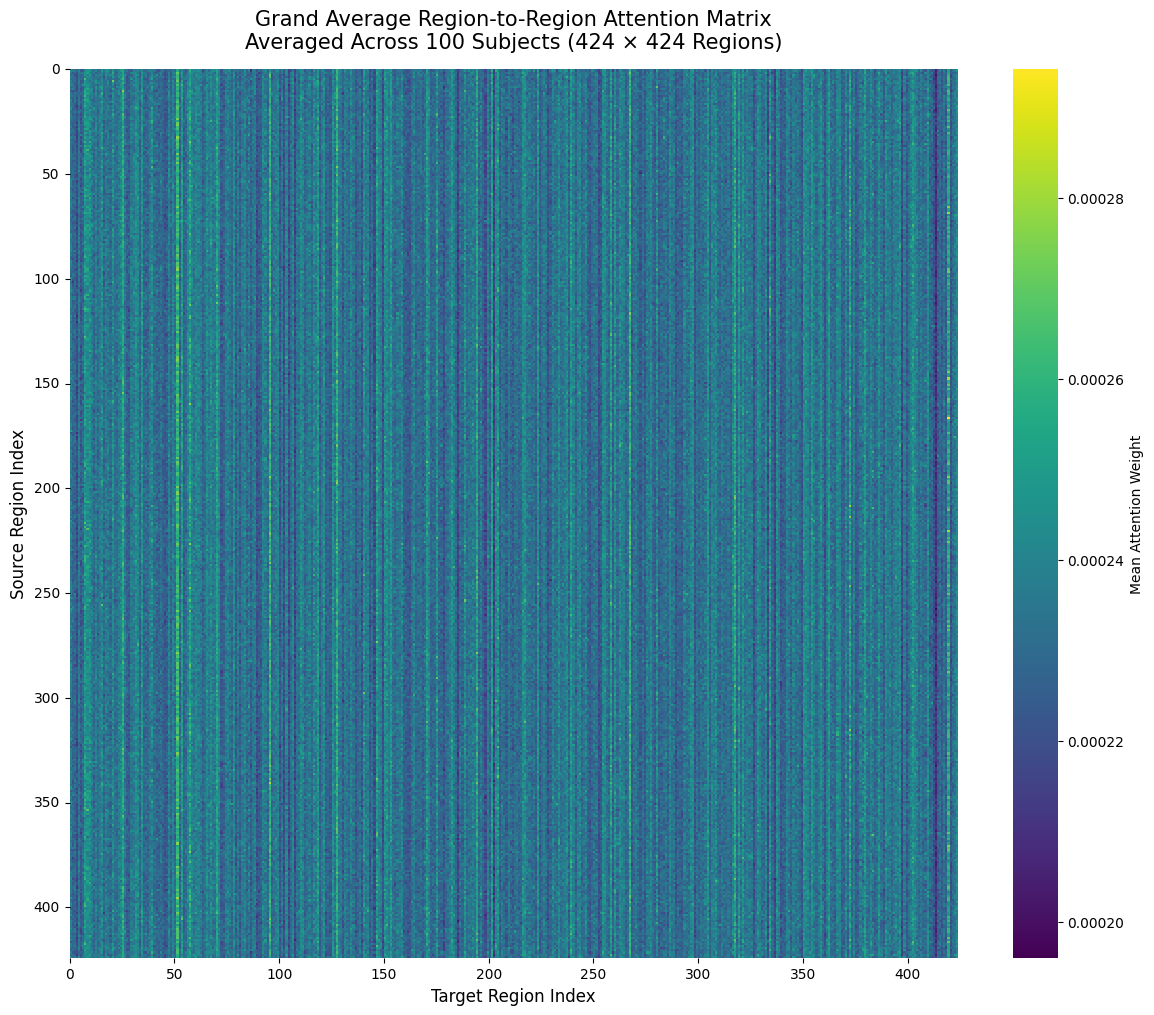

In [12]:

# ==========================================
# 3. VISUALIZATION
# ==========================================
# Set up a large figure to comfortably fit the 424x424 resolution
plt.figure(figsize=(12, 10))

# Plot the heatmap
# rasterized=True is crucial here so the notebook doesn't lag rendering 179,000 individual cells
ax = sns.heatmap(
    grand_avg_matrix, 
    cmap='viridis', 
    square=True, 
    rasterized=True,
    cbar_kws={'label': 'Mean Attention Weight'}
)

# Title and Labels
plt.title(
    f"Grand Average Region-to-Region Attention Matrix\n"
    f"Averaged Across {len(file_paths)} Subjects (424 × 424 Regions)", 
    fontsize=15, pad=15
)
plt.xlabel("Target Region Index", fontsize=12)
plt.ylabel("Source Region Index", fontsize=12)

# Format ticks cleanly (showing every 50th region prevents overlapping text)
tick_intervals = np.arange(0, 425, 50)
plt.xticks(tick_intervals, tick_intervals, rotation=0, fontsize=10)
plt.yticks(tick_intervals, tick_intervals, rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

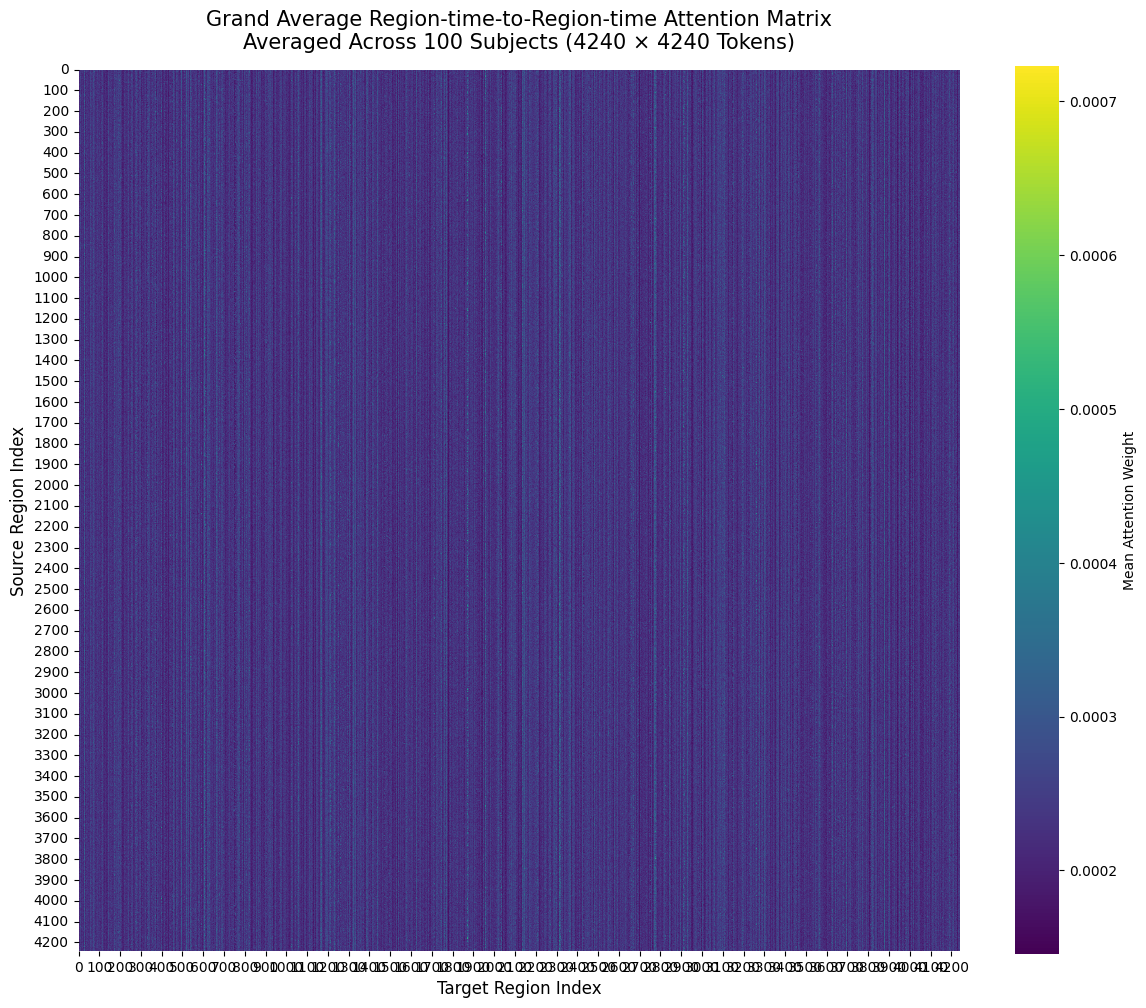

In [ ]:

# ==========================================
# 3. VISUALIZATION
# ==========================================
# Set up a large figure to comfortably fit the 424x424 resolution
plt.figure(figsize=(12, 10))

# Plot the heatmap
# rasterized=True is crucial here so the notebook doesn't lag rendering 179,000 individual cells
ax = sns.heatmap(
    grand_avg_matrix_full[3], 
    cmap='viridis', 
    square=True, 
    rasterized=True,
    cbar_kws={'label': 'Mean Attention Weight'}
)

# Title and Labels
plt.title(
    f"Grand Average Region-time-to-Region-time Attention Matrix\n"
    f"Averaged Across {len(file_paths)} Subjects (4240 × 4240 Tokens)", 
    fontsize=15, pad=15
)
plt.xlabel("Target Region Index", fontsize=12)
plt.ylabel("Source Region Index", fontsize=12)

# Format ticks cleanly 
tick_intervals = np.arange(0, 4240, 100)
plt.xticks(tick_intervals, tick_intervals, rotation=0, fontsize=10)
plt.yticks(tick_intervals, tick_intervals, rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

Selected regions

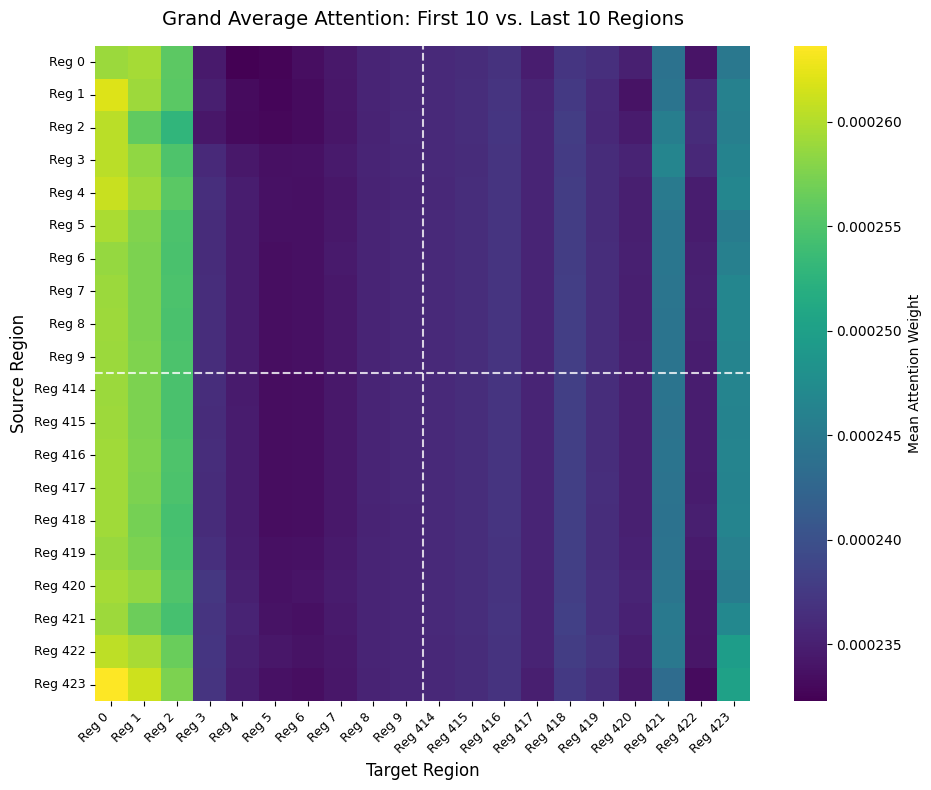

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SLICE THE GRAND AVERAGE MATRIX
# ==========================================
# Get the indices for the first 10 and last 10 regions
num_regions = grand_avg_matrix.shape[0]
first_10_idx = np.arange(0, 10)
last_10_idx = np.arange(num_regions - 10, num_regions)

# Combine them into a single array of 20 indices
selected_indices = np.concatenate([first_10_idx, last_10_idx])

# Extract the 20x20 sub-matrix using np.ix_ to slice both rows and columns
sub_matrix = grand_avg_matrix[np.ix_(selected_indices, selected_indices)]

# ==========================================
# 2. PREPARE CUSTOM LABELS
# ==========================================
# Generate labels so the axes show the actual region numbers (e.g., "Reg 0", "Reg 423")
labels = [f"Reg {i}" for i in selected_indices]

# ==========================================
# 3. VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    sub_matrix, 
    cmap='viridis', 
    square=True, 
    cbar_kws={'label': 'Mean Attention Weight'}
)

# Draw a dividing line at index 10 to show the gap between the two regional blocks
ax.axhline(10, color='white', lw=1.5, linestyle='--', alpha=0.8)
ax.axvline(10, color='white', lw=1.5, linestyle='--', alpha=0.8)

# Formatting and Titles
plt.title("Grand Average Attention: First 10 vs. Last 10 Regions", fontsize=14, pad=15)
plt.xlabel("Target Region", fontsize=12)
plt.ylabel("Source Region", fontsize=12)

# Apply the custom labels exactly in the center of each cell (+0.5 offset)
tick_positions = np.arange(len(labels)) + 0.5
plt.xticks(tick_positions, labels, rotation=45, ha='right', fontsize=9)
plt.yticks(tick_positions, labels, rotation=0, fontsize=9)

plt.tight_layout()
plt.show()